# Notebook 06 — Results & Comparison (Thesis Figures + Tables)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

FIG_DIR = Path("../reports/figures")
TAB_DIR = Path("../reports/tables")
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

MULTISEED = Path("../checkpoints/multiseed")

# Clean, print-friendly style (greyscale-safe; no reliance on colour to distinguish models)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
GREY = ["#3b3b3b", "#7a7a7a", "#a9a9a9", "#cccccc"]
HATCH = ["", "//", "..", "xx"]

## 1. Load multi-seed results (M0, M2) from the real run

In [2]:
res = pd.read_csv(MULTISEED / "results.csv").sort_values("seed").reset_index(drop=True)
print(f"loaded {len(res)} seeds from {MULTISEED/'results.csv'}")
print(res.to_string(index=False))

def ms(col):
    return res[col].mean(), res[col].std(ddof=1)

m0_em, m0_em_sd = ms("M0_EM")
m2_em, m2_em_sd = ms("M2_EM")
m0_seen, m0_seen_sd = ms("M0_seenEM")
m2_seen, m2_seen_sd = ms("M2_seenEM")
m0_cer, m0_cer_sd = ms("M0_CER")
m2_cer, m2_cer_sd = ms("M2_CER")
m0_unseen, _ = ms("M0_unseenEM")
m2_unseen, _ = ms("M2_unseenEM")

loaded 5 seeds from ../checkpoints/multiseed/results.csv
 seed   M0_CER    M0_EM  M0_seenEM  M0_unseenEM   M2_CER    M2_EM  M2_seenEM  M2_unseenEM
   42 0.459280 0.206068   0.265041          0.0 0.464820 0.351454   0.452033          0.0
   43 0.484026 0.125158   0.160976          0.0 0.487350 0.294564   0.378862          0.0
   44 0.469806 0.189633   0.243902          0.0 0.470545 0.347661   0.447154          0.0
   45 0.557156 0.067004   0.086179          0.0 0.581717 0.193426   0.248780          0.0
   46 0.434164 0.213654   0.274797          0.0 0.428624 0.388116   0.499187          0.0


## 2. Non-multi-seed results — ENTER FROM YOUR SAVED RUNS
These were single runs (encoder ablation) or evaluation-only (M3). Update if your numbers
differ. Marked with a dagger (†) in the table to denote single-run (no ± std).

In [3]:
# M1  = CNN + Transformer encoder + CTC      (single run)
# M1b = CNN + BiLSTM + Transformer + CTC     (single run)
# M3  = structured {name,strength,unit}      (name-field accuracy; dosage subset n=29 -> 0)
single_runs = {
    "M1 (CNN+Transformer+CTC)":          {"CER": 0.474, "EM": 0.222, "seenEM": 0.287, "unseenEM": 0.000},
    "M1b (CNN+BiLSTM+Transformer+CTC)":  {"CER": 0.597, "EM": 0.140, "seenEM": 0.181, "unseenEM": 0.000},
}
# M3 name-field accuracy (single representative checkpoint). Dosage-field accuracy was 0 on
# the n=29 dosage subset (documented limitation), so EM here = name accuracy.
m3_name_acc = 0.306

## 3. Master comparison table

In [4]:
def pm(mean, sd):
    return f"{mean:.3f} ± {sd:.3f}"

table = pd.DataFrame([
    {"Model": "M0 CRNN baseline",            "CER": pm(m0_cer, m0_cer_sd), "ExactMatch": pm(m0_em, m0_em_sd),
     "Seen EM": pm(m0_seen, m0_seen_sd),     "Unseen EM": f"{m0_unseen:.3f}", "Note": "5-seed mean±std"},
    {"Model": "M1 CNN+Transformer+CTC †",    "CER": f"{single_runs['M1 (CNN+Transformer+CTC)']['CER']:.3f}",
     "ExactMatch": f"{single_runs['M1 (CNN+Transformer+CTC)']['EM']:.3f}",
     "Seen EM": f"{single_runs['M1 (CNN+Transformer+CTC)']['seenEM']:.3f}",
     "Unseen EM": "0.000", "Note": "single run (negative result)"},
    {"Model": "M1b CRNN+self-attention †",   "CER": f"{single_runs['M1b (CNN+BiLSTM+Transformer+CTC)']['CER']:.3f}",
     "ExactMatch": f"{single_runs['M1b (CNN+BiLSTM+Transformer+CTC)']['EM']:.3f}",
     "Seen EM": f"{single_runs['M1b (CNN+BiLSTM+Transformer+CTC)']['seenEM']:.3f}",
     "Unseen EM": "0.000", "Note": "single run (negative result)"},
    {"Model": "M2 CRNN + lexicon",           "CER": pm(m2_cer, m2_cer_sd), "ExactMatch": pm(m2_em, m2_em_sd),
     "Seen EM": pm(m2_seen, m2_seen_sd),     "Unseen EM": f"{m2_unseen:.3f}", "Note": "5-seed mean±std — HEADLINE"},
    {"Model": "M3 structured (name field) †","CER": "—", "ExactMatch": f"{m3_name_acc:.3f}",
     "Seen EM": "—", "Unseen EM": "—", "Note": "dosage subset n=29 → 0 (limitation)"},
])
print(table.to_string(index=False))
table.to_csv(TAB_DIR / "master_comparison.csv", index=False)
print(f"\nsaved -> {TAB_DIR/'master_comparison.csv'}")

                       Model           CER    ExactMatch       Seen EM Unseen EM                                Note
            M0 CRNN baseline 0.481 ± 0.046 0.160 ± 0.063 0.206 ± 0.081     0.000                     5-seed mean±std
    M1 CNN+Transformer+CTC †         0.474         0.222         0.287     0.000        single run (negative result)
   M1b CRNN+self-attention †         0.597         0.140         0.181     0.000        single run (negative result)
           M2 CRNN + lexicon 0.487 ± 0.057 0.315 ± 0.076 0.405 ± 0.097     0.000          5-seed mean±std — HEADLINE
M3 structured (name field) †             —         0.306             —         — dosage subset n=29 → 0 (limitation)

saved -> ../reports/tables/master_comparison.csv


## 4. Figure 1 — Exact-match across models (the headline visual)

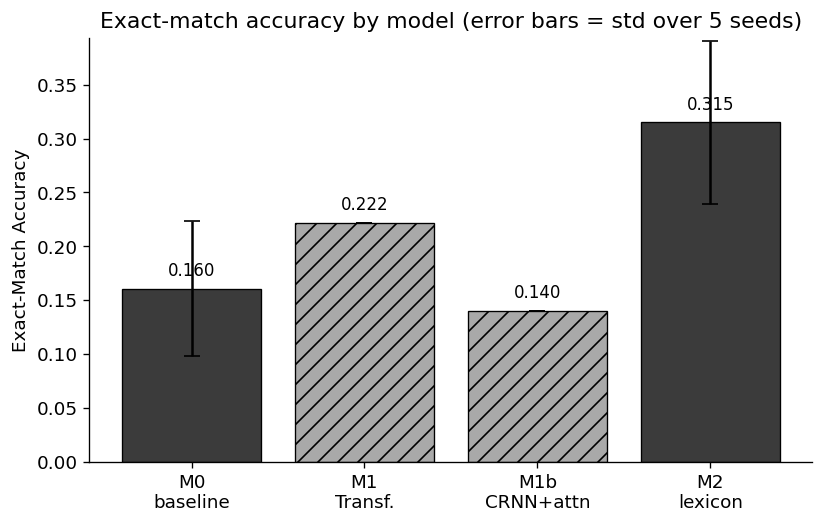

In [5]:
models = ["M0\nbaseline", "M1\nTransf.", "M1b\nCRNN+attn", "M2\nlexicon"]
ems = [m0_em, single_runs['M1 (CNN+Transformer+CTC)']['EM'],
       single_runs['M1b (CNN+BiLSTM+Transformer+CTC)']['EM'], m2_em]
errs = [m0_em_sd, 0, 0, m2_em_sd]                      # only M0/M2 have std

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(models, ems, yerr=errs, capsize=5,
              color=[GREY[0], GREY[2], GREY[2], GREY[0]],
              edgecolor="black", linewidth=0.8)
for b in (bars[1], bars[2]):
    b.set_hatch("//")                                  # mark single-run encoder variants
ax.set_ylabel("Exact-Match Accuracy")
ax.set_title("Exact-match accuracy by model (error bars = std over 5 seeds)")
for b, v in zip(bars, ems):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0, max(ems) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig1_exactmatch_by_model.png"); plt.show()

## 5. Figure 2 — Seen vs Unseen vocabulary (core finding + limitation in one chart)

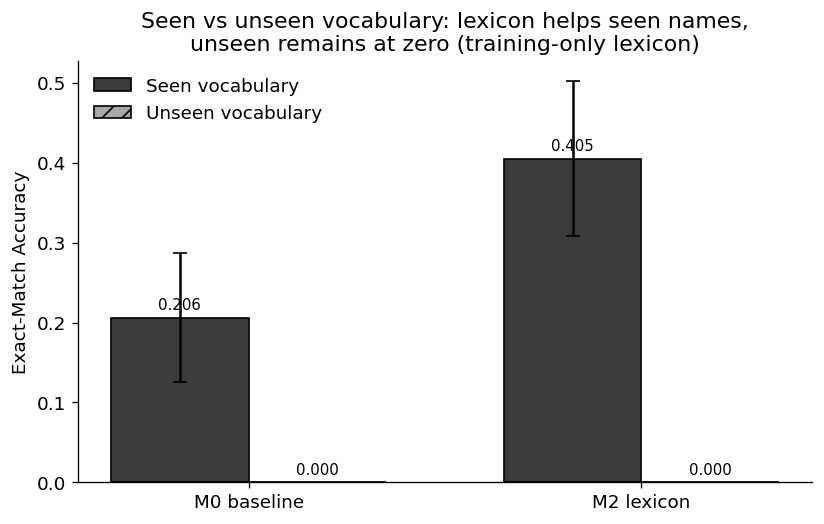

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2); w = 0.35
seen_vals = [m0_seen, m2_seen]; unseen_vals = [m0_unseen, m2_unseen]
b1 = ax.bar(x - w/2, seen_vals, w, yerr=[m0_seen_sd, m2_seen_sd], capsize=4,
            label="Seen vocabulary", color=GREY[0], edgecolor="black")
b2 = ax.bar(x + w/2, unseen_vals, w, label="Unseen vocabulary",
            color=GREY[2], edgecolor="black", hatch="//")
ax.set_xticks(x); ax.set_xticklabels(["M0 baseline", "M2 lexicon"])
ax.set_ylabel("Exact-Match Accuracy")
ax.set_title("Seen vs unseen vocabulary: lexicon helps seen names,\nunseen remains at zero (training-only lexicon)")
ax.legend(frameon=False)
for b, v in zip(b1, seen_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
for b, v in zip(b2, unseen_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig2_seen_vs_unseen.png"); plt.show()

## 6. Figure 3 — Safety analysis: lexicon fixes vs breaks (pooled over seeds)
Reads the per-example paired outcomes saved by Notebook 04 to count fixes/breaks exactly.

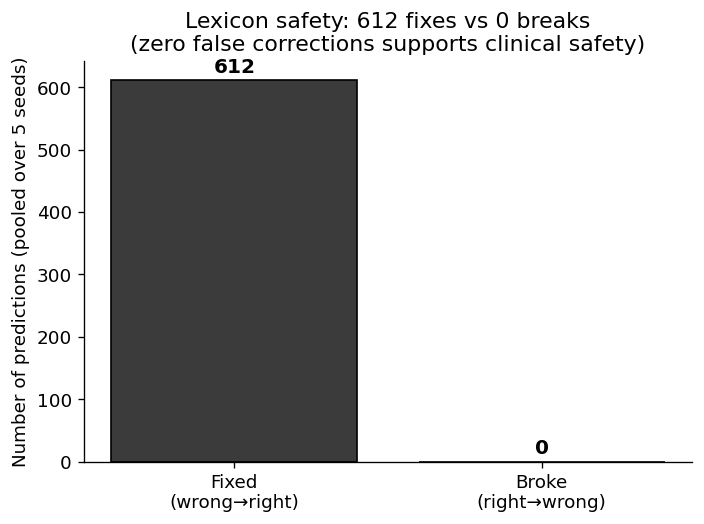

In [7]:
b_break = c_fix = harmless = 0
for seed in res["seed"]:
    f = MULTISEED / f"paired_seed{seed}.npz"
    if f.exists():
        d = np.load(f)
        m0c, m2c = d["m0"], d["m2"]
        c_fix += int(np.sum((m0c == 0) & (m2c == 1)))
        b_break += int(np.sum((m0c == 1) & (m2c == 0)))

fig, ax = plt.subplots(figsize=(6, 4.5))
cats = ["Fixed\n(wrong→right)", "Broke\n(right→wrong)"]
vals = [c_fix, b_break]
bars = ax.bar(cats, vals, color=[GREY[0], "#b22222"], edgecolor="black")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v + max(vals)*0.02, str(v), ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of predictions (pooled over 5 seeds)")
ax.set_title(f"Lexicon safety: {c_fix} fixes vs {b_break} breaks\n(zero false corrections supports clinical safety)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig3_safety_fixes_vs_breaks.png"); plt.show()

## 7. Significance results (for the thesis text)

In [8]:
t_stat, t_p = stats.ttest_rel(res["M2_EM"], res["M0_EM"])
n_disc = c_fix + b_break
mcnemar_p = stats.binomtest(min(c_fix, b_break), n_disc, 0.5).pvalue if n_disc else 1.0

sig = pd.DataFrame([
    {"test": "Paired t-test (per-seed EM)", "statistic": f"t = {t_stat:.3f}",
     "p_value": f"{t_p:.3g}", "n": f"{len(res)} seeds"},
    {"test": "McNemar (pooled per-example)", "statistic": f"fixes={c_fix}, breaks={b_break}",
     "p_value": f"{mcnemar_p:.3g}", "n": f"{n_disc} discordant"},
])
print(sig.to_string(index=False))
sig.to_csv(TAB_DIR / "significance_tests.csv", index=False)

print(f"""
THESIS SENTENCE (verify the numbers):
"Lexicon-constrained decoding raised exact-match accuracy from {m0_em:.3f} ± {m0_em_sd:.3f}
to {m2_em:.3f} ± {m2_em_sd:.3f} across five seeds. The improvement is statistically
significant (paired t-test p = {t_p:.3g}; McNemar p = {mcnemar_p:.3g}), correcting {c_fix}
predictions while breaking {b_break} — supporting the safety of the approach."
""")

                        test           statistic   p_value              n
 Paired t-test (per-seed EM)          t = 17.842   5.8e-05        5 seeds
McNemar (pooled per-example) fixes=612, breaks=0 1.18e-184 612 discordant

THESIS SENTENCE (verify the numbers):
"Lexicon-constrained decoding raised exact-match accuracy from 0.160 ± 0.063
to 0.315 ± 0.076 across five seeds. The improvement is statistically
significant (paired t-test p = 5.8e-05; McNemar p = 1.18e-184), correcting 612
predictions while breaking 0 — supporting the safety of the approach."



## 8. Figure 4 — Baseline learning curve (optional)
If you saved per-epoch val CER for one seed, drop it in here. Otherwise this cell is skipped.
(The multi-seed notebook prints per-epoch val CER every 10 epochs; you can paste one seed's
values into `curve` below to render a clean figure.)

In [9]:
curve = []   # e.g. [(1,1.00),(10,0.84),(20,0.80),...]  paste from a seed's heartbeat log
if curve:
    ep, cer = zip(*curve)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ep, cer, marker="o", color=GREY[0])
    ax.set_xlabel("epoch"); ax.set_ylabel("validation CER")
    ax.set_title("Baseline CRNN training curve (representative seed)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "fig4_baseline_learning_curve.png"); plt.show()
else:
    print("No learning-curve data entered — paste one seed's (epoch, val_CER) pairs into "
          "`curve` to render fig4. Optional.")

No learning-curve data entered — paste one seed's (epoch, val_CER) pairs into `curve` to render fig4. Optional.


## 9. Saved outputs
- tables: `reports/tables/master_comparison.csv`, `significance_tests.csv`
- figures: `reports/figures/fig1..fig3` (+ fig4 if curve data added)

These are your Results-chapter assets. Recommended figure order in the thesis:
Fig 1 (headline comparison) → Fig 2 (seen/unseen = finding + limitation) →
Fig 3 (safety) → significance table. Fig 4 (learning curve) supports the methodology.